## before visualization

In [ ]:
!pip install afinn pandas numpy nltk rpy2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for afinn: filename=afinn-0.1-py3-none-any.whl size=53431 sha256=72fcf0b0eb8d17833e28857c75b0bdb0e3cf11c5613ba63e4b8db2bcb90dbed2
  Stored in directory: /root/.cache/pip/wheels/f9/72/27/74994e77200dae3d6aea2b546264500cee21f738c51241320b
Successfully built afinn


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
from collections import Counter
from afinn import Afinn

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

nltk.download("punkt")
nltk.download("stopwords")

pandas2ri.activate()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
FILE_NAME = "bsp_speech_dataset.csv"

df = pd.read_csv(FILE_NAME)

print("Initial shape:", df.shape)
print(df.columns.tolist())

df.head()

Initial shape: (676, 11)
['index', 'Title', 'Date', 'Location', 'Occasion', 'Speaker', 'Text', 'Len', 'Link', 'last_name', 'year']


,index,Title,Date,Location,Occasion,Speaker,Text,Len,Link,last_name,year
0,0,Staying on Track in 2020: Sustaining Positive ...,3/3/20,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,"The Manila Times President and CEO, Mr. Dante ...",2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
1,1,Finding Opportunities in a Borderless World,2/28/20,"El Nido, Palawan",13th Annual FMAP Convention,BSP Governor Benjamin E. Diokno,To the officers and members of the Fund Manage...,2672,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
2,2,Gearing up for the Road Ahead: With Foresight ...,2/27/20,Sofitel Philippine Plaza Hotel,17th Professional Insurance and Financial Advi...,BSP Governor Benjamin E. Diokno,Officers and members of the Professional Insur...,2922,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
3,3,A Strong Nation Amid A Slowing and Volatile World,2/6/20,"Shangri-La at the Fort, Taguig",General Membership Meeting and Economic Briefing,BSP Governor Benjamin E. Diokno,Officers and members of the Management Associa...,2177,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
4,4,Welcome Dinner Remarks,1/31/20,Philippine International Convenion Center,BSP-BI Bilateral Meeting,BSP Governor Benjamin E. Diokno,"Governor Perry, Deputy Governors, colleagues f...",357,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020


In [ ]:
required_cols = [
    "index", "Title", "Date", "Location", "Occasion",
    "Speaker", "Text", "Len", "Link", "last_name", "year"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()

df = df.dropna(subset=["Text"]).copy()
df["Text"] = df["Text"].astype(str)
df = df[df["Text"].str.strip() != ""].copy()

print("Shape after removing missing/blank Text:", df.shape)

Shape after removing missing/blank Text: (676, 11)


In [ ]:
def normalize_for_dup(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

df["text_norm_dup"] = df["Text"].apply(normalize_for_dup)

df = df.sort_values(by=["text_norm_dup", "Len"], ascending=[True, False]).copy()

before = len(df)
df = df.drop_duplicates(subset=["text_norm_dup"], keep="first").copy()
after = len(df)

print("Number of duplicate speeches dropped:", before - after)
print("Remaining number of speeches:", after)

df = df.sort_values("index").reset_index(drop=True)

Number of duplicate speeches dropped: 0
Remaining number of speeches: 676


In [ ]:
def clean_text_for_lexicon(text):
    text = str(text).lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"_+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = df["Text"].apply(clean_text_for_lexicon)
df["tokens"] = df["text_clean"].str.split()

df[["index", "Title", "text_clean", "tokens"]].head()

,index,Title,text_clean,tokens
0,0,Staying on Track in 2020: Sustaining Positive ...,the manila times president and ceo mr dante an...,"[the, manila, times, president, and, ceo, mr, ..."
1,1,Finding Opportunities in a Borderless World,to the officers and members of the fund manage...,"[to, the, officers, and, members, of, the, fun..."
2,2,Gearing up for the Road Ahead: With Foresight ...,officers and members of the professional insur...,"[officers, and, members, of, the, professional..."
3,3,A Strong Nation Amid A Slowing and Volatile World,officers and members of the management associa...,"[officers, and, members, of, the, management, ..."
4,4,Welcome Dinner Remarks,governor perry deputy governors colleagues fro...,"[governor, perry, deputy, governors, colleague..."


In [ ]:
afinn = Afinn()

# Build Python AFINN lexicon dictionary
# This gives a word -> score dictionary
afinn_dict = afinn._dict
len(afinn_dict), list(afinn_dict.items())[:10]

(3382,
 [('abandon', -2),
  ('abandoned', -2),
  ('abandons', -2),
  ('abducted', -2),
  ('abduction', -2),
  ('abductions', -2),
  ('abhor', -3),
  ('abhorred', -3),
  ('abhorrent', -3),
  ('abhors', -3)])

In [ ]:
def normalized_weighted_sentiment(tokens, lexicon_dict):
    """
    Computes normalized weighted sentiment index:
        sum(f(w)*s(w)) / sum(f(w)*|s(w)|)
    Returns NaN if no lexicon words are matched.
    """
    counts = Counter(tokens)

    numerator = 0.0
    denominator = 0.0
    matched_words = 0

    for word, freq in counts.items():
        if word in lexicon_dict:
            score = lexicon_dict[word]
            numerator += freq * score
            denominator += freq * abs(score)
            matched_words += freq

    if denominator == 0:
        return np.nan

    return numerator / denominator

In [ ]:
df["sentiment_afinn_norm"] = df["tokens"].apply(lambda x: normalized_weighted_sentiment(x, afinn_dict))

df[["index", "Title", "sentiment_afinn_norm"]].head()

,index,Title,sentiment_afinn_norm
0,0,Staying on Track in 2020: Sustaining Positive ...,0.456954
1,1,Finding Opportunities in a Borderless World,0.745318
2,2,Gearing up for the Road Ahead: With Foresight ...,0.450980
3,3,A Strong Nation Amid A Slowing and Volatile World,0.388013
4,4,Welcome Dinner Remarks,0.946667


In [ ]:
# --- Keep your old working lexicon extraction for syuzhet and nrc ---
ro.r('''
if (!requireNamespace("syuzhet", quietly = TRUE)) {
  install.packages("syuzhet", repos = "https://cloud.r-project.org")
}
library(syuzhet)

syuzhet_lexicon <- get_sentiment_dictionary("syuzhet")
nrc_lexicon     <- get_sentiment_dictionary("nrc")
''')

# Pull working lexicons into Python
syuzhet_lexicon = pandas2ri.rpy2py(ro.globalenv["syuzhet_lexicon"])
nrc_lexicon = pandas2ri.rpy2py(ro.globalenv["nrc_lexicon"])

# --- Fix only Bing using tidytext ---
ro.r('''
if (!requireNamespace("tidytext", quietly = TRUE)) {
  install.packages("tidytext", repos = "https://cloud.r-project.org")
}
library(tidytext)

bing_tbl <- get_sentiments("bing")
bing_tbl$value <- ifelse(bing_tbl$sentiment == "positive", 1, -1)
bing_lexicon <- bing_tbl[, c("word", "value")]
''')

bing_lexicon = pandas2ri.rpy2py(ro.globalenv["bing_lexicon"])

print("Syuzhet preview:")
print(syuzhet_lexicon.head())

print("\nBing preview:")
print(bing_lexicon.head())

print("\nNRC preview:")
print(nrc_lexicon.head())

(as ‘lib’ is unspecified)










	‘/tmp/RtmpZqKVV9/downloaded_packages’

(as ‘lib’ is unspecified)








	‘/tmp/RtmpZqKVV9/downloaded_packages’



Syuzhet preview:
          word  value
1      abandon  -0.75
2    abandoned  -0.50
3    abandoner  -0.25
4  abandonment  -0.25
5     abandons  -1.00

Bing preview:
         word  value
1     2-faces   -1.0
2    abnormal   -1.0
3     abolish   -1.0
4  abominable   -1.0
5  abominably   -1.0

NRC preview:
      lang            word sentiment  value
1  english            abba  positive    1.0
2  english         ability  positive    1.0
3  english  abovementioned  positive    1.0
4  english        absolute  positive    1.0
5  english      absolution  positive    1.0


In [ ]:
# --- Syuzhet ---
# adjust only if needed after checking the preview
syuzhet_dict = dict(zip(syuzhet_lexicon["word"], syuzhet_lexicon["value"]))

# --- Bing ---
bing_dict = dict(zip(bing_lexicon["word"], bing_lexicon["value"]))

# --- NRC ---
# keep only positive and negative and encode as +1 / -1
nrc_posneg = nrc_lexicon[nrc_lexicon["sentiment"].isin(["positive", "negative"])].copy()
nrc_posneg["value"] = nrc_posneg["sentiment"].map({"positive": 1, "negative": -1})

# in case words appear twice, aggregate them
nrc_dict = nrc_posneg.groupby("word")["value"].sum().to_dict()

print("Sample Bing dictionary entries:")
print(list(bing_dict.items())[:10])

Sample Bing dictionary entries:
[('2-faces', -1.0), ('abnormal', -1.0), ('abolish', -1.0), ('abominable', -1.0), ('abominably', -1.0), ('abominate', -1.0), ('abomination', -1.0), ('abort', -1.0), ('aborted', -1.0), ('aborts', -1.0)]


In [ ]:
df["sentiment_syuzhet_norm"] = df["tokens"].apply(
    lambda x: normalized_weighted_sentiment(x, syuzhet_dict)
)

df["sentiment_bing_norm"] = df["tokens"].apply(
    lambda x: normalized_weighted_sentiment(x, bing_dict)
)

df["sentiment_nrc_norm"] = df["tokens"].apply(
    lambda x: normalized_weighted_sentiment(x, nrc_dict)
)

df[[
    "index", "Title",
    "sentiment_afinn_norm",
    "sentiment_syuzhet_norm",
    "sentiment_bing_norm",
    "sentiment_nrc_norm"
]].head()

,index,Title,sentiment_afinn_norm,sentiment_syuzhet_norm,sentiment_bing_norm,sentiment_nrc_norm
0,0,Staying on Track in 2020: Sustaining Positive ...,0.456954,0.446168,0.411765,0.421053
1,1,Finding Opportunities in a Borderless World,0.745318,0.706990,0.680556,0.633333
2,2,Gearing up for the Road Ahead: With Foresight ...,0.450980,0.459251,0.483568,0.414925
3,3,A Strong Nation Amid A Slowing and Volatile World,0.388013,0.402182,0.432258,0.354086
4,4,Welcome Dinner Remarks,0.946667,0.982238,0.920000,1.000000


In [ ]:
# OPTIONAL AVERAGE COUNTS

def matched_word_count(tokens, lexicon_dict):
    counts = Counter(tokens)
    return sum(freq for word, freq in counts.items() if word in lexicon_dict)

df["afinn_matched_words"] = df["tokens"].apply(lambda x: matched_word_count(x, afinn_dict))
df["syuzhet_matched_words"] = df["tokens"].apply(lambda x: matched_word_count(x, syuzhet_dict))
df["bing_matched_words"] = df["tokens"].apply(lambda x: matched_word_count(x, bing_dict))
df["nrc_matched_words"] = df["tokens"].apply(lambda x: matched_word_count(x, nrc_dict))

df[[
    "index",
    "afinn_matched_words",
    "syuzhet_matched_words",
    "bing_matched_words",
    "nrc_matched_words"
]].head()

,index,afinn_matched_words,syuzhet_matched_words,bing_matched_words,nrc_matched_words
0,0,178,416,153,271
1,1,144,358,144,247
2,2,233,511,213,342
3,3,175,383,155,266
4,4,37,53,25,37


In [ ]:
df["total_words"] = df["tokens"].apply(len)

df["afinn_coverage_ratio"] = df["afinn_matched_words"] / df["total_words"]
df["syuzhet_coverage_ratio"] = df["syuzhet_matched_words"] / df["total_words"]
df["bing_coverage_ratio"] = df["bing_matched_words"] / df["total_words"]
df["nrc_coverage_ratio"] = df["nrc_matched_words"] / df["total_words"]

In [ ]:
final_scores_norm = df[[
    "index", "Title", "Date", "Location", "Occasion", "Speaker",
    "last_name", "year", "Len", "Link",
    "sentiment_afinn_norm",
    "sentiment_syuzhet_norm",
    "sentiment_bing_norm",
    "sentiment_nrc_norm",
    "afinn_matched_words",
    "syuzhet_matched_words",
    "bing_matched_words",
    "nrc_matched_words",
    "afinn_coverage_ratio",
    "syuzhet_coverage_ratio",
    "bing_coverage_ratio",
    "nrc_coverage_ratio"
]].copy()

final_scores_norm.head()

,index,Title,Date,Location,Occasion,Speaker,last_name,year,Len,Link,...,sentiment_bing_norm,sentiment_nrc_norm,afinn_matched_words,syuzhet_matched_words,bing_matched_words,nrc_matched_words,afinn_coverage_ratio,syuzhet_coverage_ratio,bing_coverage_ratio,nrc_coverage_ratio
0,0,Staying on Track in 2020: Sustaining Positive ...,3/3/20,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,Diokno,2020,2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.411765,0.421053,178,416,153,271,0.072981,0.170562,0.062731,0.111111
1,1,Finding Opportunities in a Borderless World,2/28/20,"El Nido, Palawan",13th Annual FMAP Convention,BSP Governor Benjamin E. Diokno,Diokno,2020,2672,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.680556,0.633333,144,358,144,247,0.054196,0.134738,0.054196,0.092962
2,2,Gearing up for the Road Ahead: With Foresight ...,2/27/20,Sofitel Philippine Plaza Hotel,17th Professional Insurance and Financial Advi...,BSP Governor Benjamin E. Diokno,Diokno,2020,2922,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.483568,0.414925,233,511,213,342,0.079822,0.175060,0.072970,0.117163
3,3,A Strong Nation Amid A Slowing and Volatile World,2/6/20,"Shangri-La at the Fort, Taguig",General Membership Meeting and Economic Briefing,BSP Governor Benjamin E. Diokno,Diokno,2020,2177,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.432258,0.354086,175,383,155,266,0.081169,0.177644,0.071892,0.123377
4,4,Welcome Dinner Remarks,1/31/20,Philippine International Convenion Center,BSP-BI Bilateral Meeting,BSP Governor Benjamin E. Diokno,Diokno,2020,357,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.920000,1.000000,37,53,25,37,0.099462,0.142473,0.067204,0.099462


In [ ]:
score_cols_norm = [
    "sentiment_afinn_norm",
    "sentiment_syuzhet_norm",
    "sentiment_bing_norm",
    "sentiment_nrc_norm"
]

summary_stats_norm = final_scores_norm[score_cols_norm].describe().T
summary_stats_norm

,count,mean,std,min,25%,50%,75%,max
sentiment_afinn_norm,676.0,0.628431,0.224873,-0.267176,0.493369,0.647970,0.796126,1.0
sentiment_syuzhet_norm,676.0,0.629668,0.181782,-0.304813,0.516151,0.636748,0.766071,1.0
sentiment_bing_norm,676.0,0.561312,0.242002,-1.000000,0.417476,0.586722,0.726555,1.0
sentiment_nrc_norm,676.0,0.600173,0.167501,-0.081081,0.486912,0.600752,0.717813,1.0


In [ ]:
# STRICT 0 NEUTRAL SENTIMENT

def count_sentiment_scores(series):
    return pd.Series({
        "Positive": (series > 0).sum(),
        "Negative": (series < 0).sum(),
        "Neutral":  (series == 0).sum(),
        "Missing":  series.isna().sum()
    })

sentiment_counts_summary_norm = pd.DataFrame({
    "AFINN": count_sentiment_scores(final_scores_norm["sentiment_afinn_norm"]),
    "Syuzhet": count_sentiment_scores(final_scores_norm["sentiment_syuzhet_norm"]),
    "Bing": count_sentiment_scores(final_scores_norm["sentiment_bing_norm"]),
    "NRC": count_sentiment_scores(final_scores_norm["sentiment_nrc_norm"])
}).T.reset_index()

sentiment_counts_summary_norm.columns = ["Metric", "Positive", "Negative", "Neutral", "Missing"]
sentiment_counts_summary_norm

,Metric,Positive,Negative,Neutral,Missing
0,AFINN,666,10,0,0
1,Syuzhet,673,3,0,0
2,Bing,664,10,2,0
3,NRC,674,2,0,0


In [ ]:
# [-0.05,0.05] Neutral Band Sentiment

def count_sentiment_scores_band(series, eps=0.05):
    return pd.Series({
        "Positive": (series > eps).sum(),
        "Negative": (series < -eps).sum(),
        "Neutral": ((series >= -eps) & (series <= eps)).sum(),
        "Missing": series.isna().sum()
    })

sentiment_counts_summary_band = pd.DataFrame({
    "AFINN": count_sentiment_scores_band(final_scores_norm["sentiment_afinn_norm"], eps=0.05),
    "Syuzhet": count_sentiment_scores_band(final_scores_norm["sentiment_syuzhet_norm"], eps=0.05),
    "Bing": count_sentiment_scores_band(final_scores_norm["sentiment_bing_norm"], eps=0.05),
    "NRC": count_sentiment_scores_band(final_scores_norm["sentiment_nrc_norm"], eps=0.05)
}).T.reset_index()

sentiment_counts_summary_band.columns = ["Metric", "Positive", "Negative", "Neutral", "Missing"]
sentiment_counts_summary_band

,Metric,Positive,Negative,Neutral,Missing
0,AFINN,661,7,8,0
1,Syuzhet,673,3,0,0
2,Bing,660,7,9,0
3,NRC,673,1,2,0


In [ ]:
final_scores_norm.to_csv("final_bsp_dictionary_sentiment_scores.csv", index=False)
summary_stats_norm.to_csv("final_bsp_dictionary_summary_stats.csv")
sentiment_counts_summary_norm.to_csv("final_bsp_dictionary_sentiment_counts.csv", index=False)

print("Files saved:")
print("- final_bsp_dictionary_sentiment_scores.csv")
print("- final_bsp_dictionary_summary_stats.csv")
print("- final_bsp_dictionary_sentiment_counts.csv")

Files saved:
- final_bsp_dictionary_sentiment_scores.csv
- final_bsp_dictionary_summary_stats.csv
- final_bsp_dictionary_sentiment_counts.csv


In [ ]:
final_scores_norm

,index,Title,Date,Location,Occasion,Speaker,last_name,year,Len,Link,...,sentiment_bing_norm,sentiment_nrc_norm,afinn_matched_words,syuzhet_matched_words,bing_matched_words,nrc_matched_words,afinn_coverage_ratio,syuzhet_coverage_ratio,bing_coverage_ratio,nrc_coverage_ratio
0,0,Staying on Track in 2020: Sustaining Positive ...,3/3/20,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,BSP Governor Benjamin E. Diokno,Diokno,2020,2444,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.411765,0.421053,178,416,153,271,0.072981,0.170562,0.062731,0.111111
1,1,Finding Opportunities in a Borderless World,2/28/20,"El Nido, Palawan",13th Annual FMAP Convention,BSP Governor Benjamin E. Diokno,Diokno,2020,2672,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.680556,0.633333,144,358,144,247,0.054196,0.134738,0.054196,0.092962
2,2,Gearing up for the Road Ahead: With Foresight ...,2/27/20,Sofitel Philippine Plaza Hotel,17th Professional Insurance and Financial Advi...,BSP Governor Benjamin E. Diokno,Diokno,2020,2922,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.483568,0.414925,233,511,213,342,0.079822,0.175060,0.072970,0.117163
3,3,A Strong Nation Amid A Slowing and Volatile World,2/6/20,"Shangri-La at the Fort, Taguig",General Membership Meeting and Economic Briefing,BSP Governor Benjamin E. Diokno,Diokno,2020,2177,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.432258,0.354086,175,383,155,266,0.081169,0.177644,0.071892,0.123377
4,4,Welcome Dinner Remarks,1/31/20,Philippine International Convenion Center,BSP-BI Bilateral Meeting,BSP Governor Benjamin E. Diokno,Diokno,2020,357,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.920000,1.000000,37,53,25,37,0.099462,0.142473,0.067204,0.099462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,674,THE PHILIPPINES: CAPITALIZING ON SUSTAINED FIN...,11/11/98,"Shangri-La Manila Hotel, Makati City",Euromoney Conference,Governor Gabriel Singson,Singson,1998,1657,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.107438,0.251613,118,222,121,157,0.073337,0.137974,0.075202,0.097576
672,675,BSP ON ITS 5TH YEAR ANNIVERSARY: MANAGING THE ...,7/3/98,BSP Cafetorium,unknown,Governor Gabriel Singson,Singson,1998,1047,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.436620,0.423423,73,158,71,112,0.071639,0.155054,0.069676,0.109912
673,676,ON WITH THE ECONOMIC RECOVERY...CAREFULLY,5/28/98,"Grand Ballroom, Hotel Intercontinental, Makati...",5th Monthly Business Meeting of the Chamber of...,Governor Gabriel Singson,Singson,1998,1601,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.263158,0.281437,107,225,95,169,0.068678,0.144416,0.060976,0.108472
674,677,An Update on Recent Economic Developments,5/22/98,"Peninsula Hotel, Makati City",Asia Society breakfast meeting,Governor Gabriel Singson,Singson,1998,1349,https://www.bsp.gov.ph/SitePages/MediaAndResea...,...,0.240506,0.231884,89,197,79,142,0.067322,0.149017,0.059758,0.107413


In [ ]:
final_scores_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   index                   676 non-null    int64  
 1   Title                   676 non-null    object 
 2   Date                    676 non-null    object 
 3   Location                676 non-null    object 
 4   Occasion                676 non-null    object 
 5   Speaker                 676 non-null    object 
 6   last_name               676 non-null    object 
 7   year                    676 non-null    int64  
 8   Len                     676 non-null    int64  
 9   Link                    676 non-null    object 
 10  sentiment_afinn_norm    676 non-null    float64
 11  sentiment_syuzhet_norm  676 non-null    float64
 12  sentiment_bing_norm     676 non-null    float64
 13  sentiment_nrc_norm      676 non-null    float64
 14  afinn_matched_words     676 non-null    in

In [ ]:
def matched_word_count(tokens, lexicon_dict):
    counts = Counter(tokens)
    return sum(freq for word, freq in counts.items() if word in lexicon_dict)

df["afinn_matched_words"] = df["tokens"].apply(lambda x: matched_word_count(x, afinn_dict))
df["syuzhet_matched_words"] = df["tokens"].apply(lambda x: matched_word_count(x, syuzhet_dict))
df["bing_matched_words"] = df["tokens"].apply(lambda x: matched_word_count(x, bing_dict))
df["nrc_matched_words"] = df["tokens"].apply(lambda x: matched_word_count(x, nrc_dict))

df[[
    "index",
    "afinn_matched_words",
    "syuzhet_matched_words",
    "bing_matched_words",
    "nrc_matched_words"
]].head()

,index,afinn_matched_words,syuzhet_matched_words,bing_matched_words,nrc_matched_words
0,0,178,416,153,271
1,1,144,358,144,247
2,2,233,511,213,342
3,3,175,383,155,266
4,4,37,53,25,37


# visualization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

score_cols_norm = [
    "sentiment_afinn_norm",
    "sentiment_syuzhet_norm",
    "sentiment_bing_norm",
    "sentiment_nrc_norm"
]

df_long_norm = final_scores_norm[["year"] + score_cols_norm].melt(
    id_vars="year",
    var_name="Method",
    value_name="Score"
)

method_map = {
    "sentiment_afinn_norm": "AFINN",
    "sentiment_syuzhet_norm": "Syuzhet",
    "sentiment_bing_norm": "Bing",
    "sentiment_nrc_norm": "NRC"
}

df_long_norm["Method"] = df_long_norm["Method"].map(method_map)

df_long_norm.head()

,year,Method,Score
0,2020,AFINN,0.456954
1,2020,AFINN,0.745318
2,2020,AFINN,0.450980
3,2020,AFINN,0.388013
4,2020,AFINN,0.946667


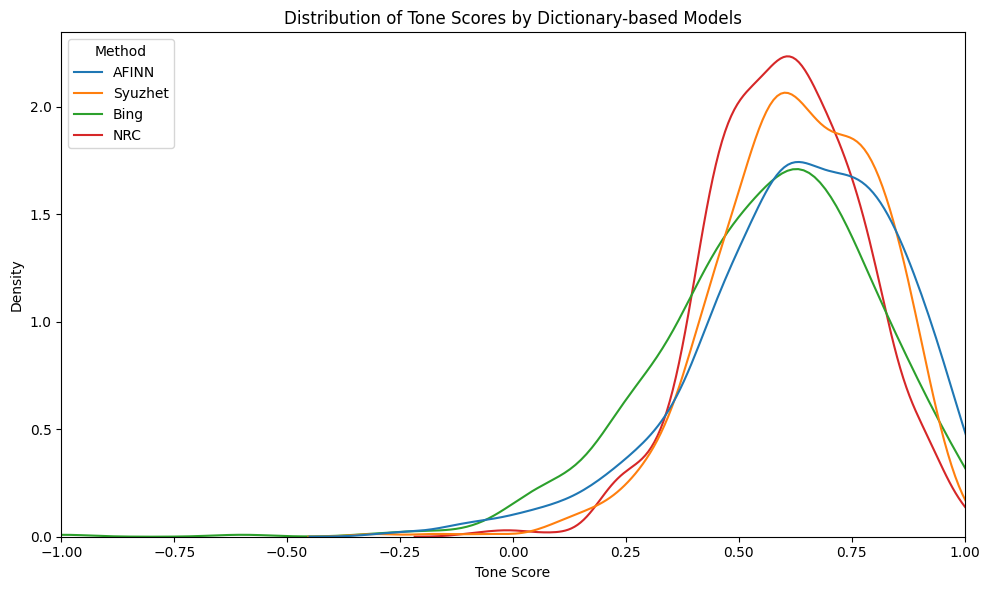

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_long_norm,
    x="Score",
    hue="Method",
    common_norm=False
)

plt.title("Distribution of Tone Scores by Dictionary-based Models")
plt.xlabel("Tone Score")
plt.ylabel("Density")
plt.xlim(-1, 1)
plt.tight_layout()
plt.show()

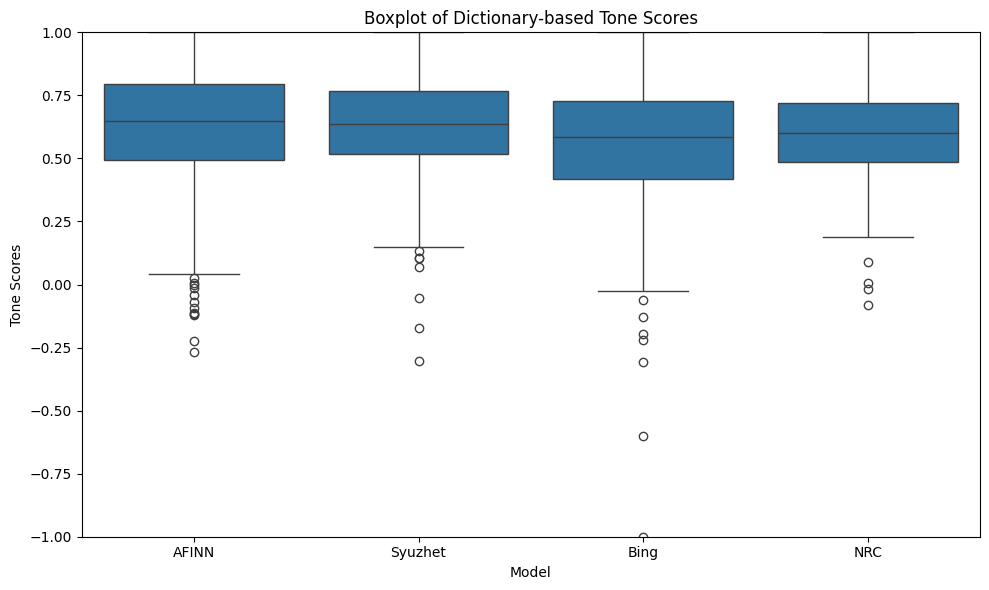

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_long_norm,
    x="Method",
    y="Score"
)

plt.title("Boxplot of Dictionary-based Tone Scores")
plt.xlabel("Model")
plt.ylabel("Tone Scores")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

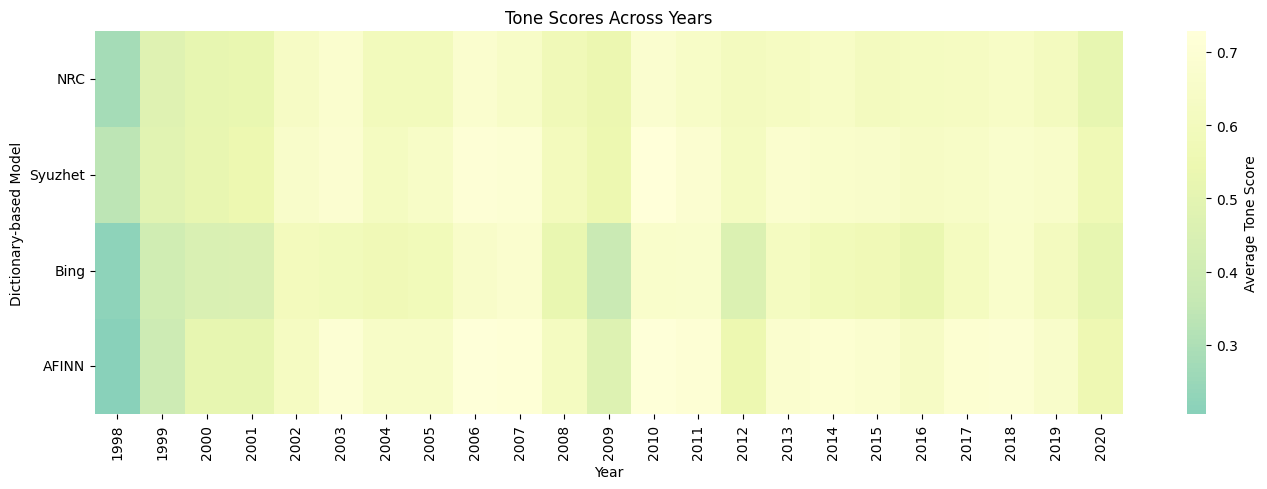

In [ ]:
# CENTERED AT 0

yearly_scores_norm = final_scores_norm.groupby("year", as_index=True)[[
    "sentiment_afinn_norm",
    "sentiment_syuzhet_norm",
    "sentiment_bing_norm",
    "sentiment_nrc_norm"
]].mean()

yearly_scores_norm = yearly_scores_norm[[
    "sentiment_nrc_norm",
    "sentiment_syuzhet_norm",
    "sentiment_bing_norm",
    "sentiment_afinn_norm"
]]

yearly_scores_norm_renamed = yearly_scores_norm.T.copy()
yearly_scores_norm_renamed.index = ["NRC", "Syuzhet", "Bing", "AFINN"]

plt.figure(figsize=(14, 5))

sns.heatmap(
    yearly_scores_norm_renamed,
    cmap="YlGnBu_r",
    center=0,
    annot=False,
    linewidths=0,
    cbar_kws={"label": "Average Tone Score"}
)

plt.title("Tone Scores Across Years")
plt.xlabel("Year")
plt.ylabel("Dictionary-based Model")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

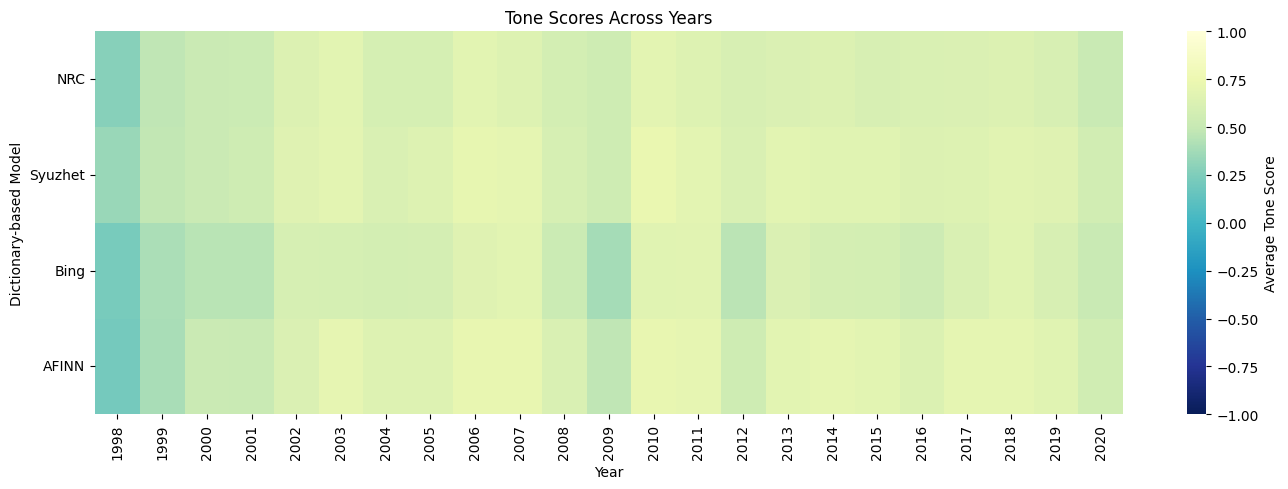

In [ ]:
# NOT CENTERED AT 0

plt.figure(figsize=(14, 5))

sns.heatmap(
    yearly_scores_norm_renamed,
    cmap="YlGnBu_r",
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0,
    cbar_kws={"label": "Average Tone Score"}
)

plt.title("Tone Scores Across Years")
plt.xlabel("Year")
plt.ylabel("Dictionary-based Model")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

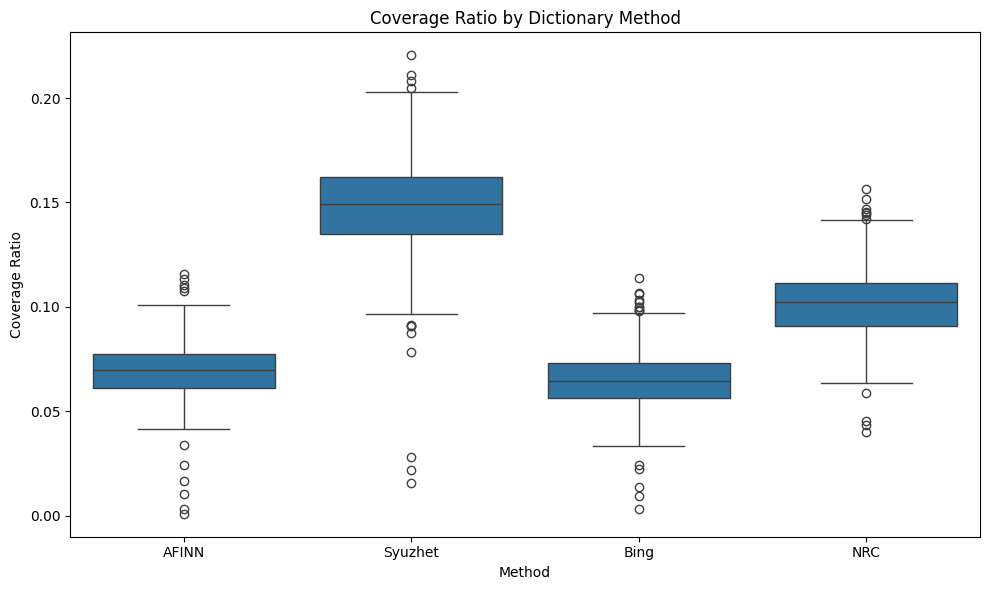

In [ ]:
coverage_cols = [
    "afinn_coverage_ratio",
    "syuzhet_coverage_ratio",
    "bing_coverage_ratio",
    "nrc_coverage_ratio"
]

coverage_df = final_scores_norm[coverage_cols].melt(
    var_name="Method",
    value_name="Coverage"
)

coverage_map = {
    "afinn_coverage_ratio": "AFINN",
    "syuzhet_coverage_ratio": "Syuzhet",
    "bing_coverage_ratio": "Bing",
    "nrc_coverage_ratio": "NRC"
}

coverage_df["Method"] = coverage_df["Method"].map(coverage_map)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=coverage_df,
    x="Method",
    y="Coverage"
)

plt.title("Coverage Ratio by Dictionary Method")
plt.xlabel("Method")
plt.ylabel("Coverage Ratio")
plt.tight_layout()
plt.show()